# Algorithme de détection de faux billets

## 1. Chargement et préparation des données

In [ ]:
# Importation des bibliothèques nécessaires
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Paramètres d'affichage
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="pastel")
%matplotlib inline

In [1]:
# Lecture (séparateur ;). 
billets_df = pd.read_csv("billets.csv", sep=';', encoding='utf-8')

# Strip : supprimer espaces en tête/fin pour les colonnes texte uniquement
for col in billets_df.select_dtypes(include=['object']).columns:
    billets_df[col] = billets_df[col].str.strip()

# Conversion des colonnes numériques (au cas où elles auraient été lues comme strings ou utilisent la virgule comme séparateur décimal)
numeric_cols = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
for col in numeric_cols:
    if col in billets_df.columns:
        # Remplacer virgule par point avant conversion puis forcer numeric
        billets_df[col] = pd.to_numeric(billets_df[col].astype(str).str.replace(',', '.'), errors='coerce')

# Vérifications rapides
print("Dimensions du dataset :", billets_df.shape)
print("\nExemple :")
display(billets_df.head())

Dimensions du dataset : (1500, 7)

Exemple :


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [2]:
# Informations générales
print("\n--- Informations ---")
print(billets_df.info())

print("\n--- Statistiques descriptives ---")
display(billets_df.describe().T)


--- Informations ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB
None

--- Statistiques descriptives ---


,count,mean,std,min,25%,50%,75%,max
diagonal,1500.0,171.958440,0.305195,171.04,171.750,171.96,172.17,173.01
height_left,1500.0,104.029533,0.299462,103.14,103.820,104.04,104.23,104.88
height_right,1500.0,103.920307,0.325627,102.82,103.710,103.92,104.15,104.95
margin_low,1463.0,4.485967,0.663813,2.98,4.015,4.31,4.87,6.90
margin_up,1500.0,3.151473,0.231813,2.27,2.990,3.14,3.31,3.91
length,1500.0,112.678500,0.872730,109.49,112.030,112.96,113.34,114.44


In [3]:
# Valeurs manquantes
print("\n--- Valeurs manquantes ---")
print(billets_df.isnull().sum())

# Doublons
nb_duplicated = billets_df.duplicated().sum()
print(f"\nNombre de doublons : {nb_duplicated}")


--- Valeurs manquantes ---
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Nombre de doublons : 0


In [4]:
# Séparation des features et de la target
features = ['length', 'height_left', 'height_right', 'margin_up', 'margin_low', 'diagonal']
target = 'is_genuine'

X = billets_df[features].copy()
y = billets_df[target].astype(int)  # conversion en 0/1

In [5]:
# Préparation pour la régression (imputation des valeurs manquantes)

from sklearn.linear_model import LinearRegression

# Séparation lignes complètes / incomplètes
df_train = billets_df[billets_df['margin_low'].notna()]
df_missing = billets_df[billets_df['margin_low'].isna()]

# X pour la régression (toutes les variables sauf margin_low et target)
X_train_reg = df_train.drop(columns=['is_genuine', 'margin_low'])
y_train_reg = df_train['margin_low']

# Entraînement du modèle
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

LinearRegression()

In [6]:
from sklearn.metrics import r2_score

# Prédictions sur l'échantillon d'entraînement
y_train_pred = lin_reg.predict(X_train_reg)

# Calcul du R²
r2 = r2_score(y_train_reg, y_train_pred)
print(f"Coefficient de détermination R² : {r2:.4f}")

Coefficient de détermination R² : 0.4773


In [7]:
# Prédiction des valeurs manquantes
X_missing_reg = df_missing.drop(columns=['is_genuine', 'margin_low'])
predicted_margin_low = lin_reg.predict(X_missing_reg)

# Création d'une copie pour tester l'imputation
billets_imputed = billets_df.copy()
billets_imputed.loc[billets_imputed['margin_low'].isna(), 'margin_low'] = predicted_margin_low

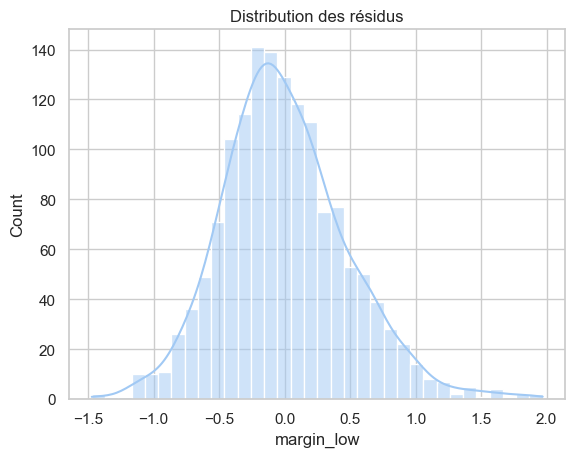

Test de Shapiro-Wilk : stat=0.986, p=0.000
→ Les résidus ne suivent PAS une distribution normale (on rejette H0)


In [8]:
# Normalité des résidus

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Calcul des résidus
y_pred_train = lin_reg.predict(X_train_reg)
residuals = y_train_reg - y_pred_train

# Histogramme des résidus
sns.histplot(residuals, kde=True)
plt.title("Distribution des résidus")
plt.show()

# Test de Shapiro-Wilk
stat, p_value = stats.shapiro(residuals)
print("Test de Shapiro-Wilk : stat=%.3f, p=%.3f" % (stat, p_value))
if p_value > 0.05:
    print("→ Les résidus suivent une distribution normale (on ne rejette pas H0)")
else:
    print("→ Les résidus ne suivent PAS une distribution normale (on rejette H0)")

In [9]:
# Colinéarité des variables (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

# Ajout d'une constante pour le calcul du VIF
X_train_reg_const = sm.add_constant(X_train_reg)

# Calcul du VIF pour chaque variable
vif = pd.DataFrame()
vif["Variable"] = X_train_reg_const.columns
vif["VIF"] = [variance_inflation_factor(X_train_reg_const.values, i)
              for i in range(X_train_reg_const.shape[1])]
print(vif)

       Variable            VIF
0         const  590198.238883
1      diagonal       1.013613
2   height_left       1.138261
3  height_right       1.230115
4     margin_up       1.404404
5        length       1.576950


In [10]:
# Homoscédasticité (test de Breusch-Pagan)

from statsmodels.stats.diagnostic import het_breuschpagan

# Test de Breusch-Pagan
bp_test = het_breuschpagan(residuals, X_train_reg_const)
labels = ['Lagrange multiplier', 'p-value', 'f-value', 'f p-value']
bp_results = dict(zip(labels, bp_test))
print(bp_results)

if bp_results['p-value'] > 0.05:
    print("→ Homoscédasticité respectée (variance constante des résidus)")
else:
    print("→ PAS d’homoscédasticité (variance non constante des résidus)")

{'Lagrange multiplier': 80.16261280175316, 'p-value': 7.759535216185222e-16, 'f-value': 16.892358846154043, 'f p-value': 2.9227496566177887e-16}
→ PAS d’homoscédasticité (variance non constante des résidus)


In [11]:
# Suppression des lignes contenant des valeurs manquantes
billets_clean = billets_df.dropna(subset=['margin_low'])

print("Nombre de lignes après suppression :", billets_clean.shape[0])

Nombre de lignes après suppression : 1463


In [12]:
billets_df = billets_clean

In [13]:
# Normalisation / Standardisation des données

from sklearn.preprocessing import StandardScaler

# Séparation features et target après imputation
X = billets_df[features].copy()
y = billets_df[target].astype(int)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Conversion en DataFrame pour rester lisible
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("Aperçu des données normalisées :")
display(X_scaled.head())

Aperçu des données normalisées :


,length,height_left,height_right,margin_up,margin_low,diagonal
0,0.177842,2.766807,3.173766,-1.136982,0.051286,-0.488594
1,0.475692,-2.241490,-0.806851,-0.704806,-1.078937,-1.634809
2,0.555882,1.498039,-1.300571,-0.920894,-0.129549,2.393318
3,0.956834,-0.405114,0.057159,-0.618370,-1.304982,-1.962299
4,-0.154375,0.830266,-1.424001,1.412861,-0.672057,-0.750586


## 2. Entrainement de l'algorithme

In [14]:
# ==============================
#  Entraînement du modèle final
# ==============================

from sklearn.linear_model import LogisticRegression

# Instanciation du modèle de régression logistique
log_reg = LogisticRegression(random_state=42, max_iter=1000)

In [15]:
# Entraînement du modèle sur toutes les données disponibles
log_reg.fit(X_scaled, y)

print("Modèle de régression logistique entraîné avec succès.")

Modèle de régression logistique entraîné avec succès.


## 3. Test sur un fichier externe

In [16]:
# ==============================
#  Application sur données externes
# ==============================

# Chargement du fichier de production
production_df = pd.read_csv("billets_production.csv", sep=",")

# Aperçu des données
print("Dimensions du fichier production :", production_df.shape)
production_df.head()

Dimensions du fichier production : (5, 7)


,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


In [17]:
# Sélection des features
X_prod = production_df[features].copy()

# Normalisation avec le scaler déjà entraîné
X_prod_scaled = scaler.transform(X_prod)

In [18]:
# Prédictions avec le modèle final
predictions = log_reg.predict(X_prod_scaled)

# Ajout des prédictions dans le DataFrame
production_df['prediction'] = predictions

C:\Users\user-aidicom\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [19]:
# Affichage du résultat
production_df

,diagonal,height_left,height_right,margin_low,margin_up,length,id,prediction
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,0
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,0
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,0
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,1
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,1


0 = billet faux, 1 = billet vrai (en accord avec le codage utilisé pour la régression logistique).

# Sauvegarde du fichier résultat avec prédictions
production_df.to_csv("billets_production_pred.csv", index=False, sep=";")
print("Fichier billets_production_pred.csv sauvegardé avec succès.")